# El Oráculo del Balón (Mundial 2026)
**Fase 1: Configuración del Entorno y Recolección de Datos**
Iniciamos creando la estructura de directorios necesaria. Para evitar el sesgo de usar datos estáticos pre-limpios, nuestro pipeline se conecta a internet para descargar el ELO histórico, la calidad de plantilla (mediante web scraping a SoFIFA) y los datos socioeconómicos de las 48 naciones participantes.

In [ ]:
import os
import pandas as pd
import requests
from bs4 import BeautifulSoup
import numpy as np
import warnings
import io
warnings.filterwarnings('ignore')

# Creamos las carpetas temporales
os.makedirs('data/raw', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)
os.makedirs('models', exist_ok=True)

print("[FASE 1] INICIANDO EXTRACCIÓN DE DATOS EN VIVO...")

# =====================================================================
# 1. PARTIDOS HISTÓRICOS (Descarga directa)
# =====================================================================
print("-> 1/4 Descargando resultados históricos internacionales...")
url_matches = "https://raw.githubusercontent.com/martj42/international_results/master/results.csv"
df_matches = pd.read_csv(url_matches)
df_matches.to_csv('data/raw/historical_results.csv', index=False)
print(f"   [OK] {len(df_matches)} partidos descargados.")

# =====================================================================
# 2. CALIDAD DE PLANTILLA (Scraping a SoFIFA)
# =====================================================================
print("-> 2/4 Haciendo scraping a SoFIFA (EA FC Data)...")
url_sofifa = "https://sofifa.com/teams?type=national"
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
    'Accept-Language': 'en-US,en;q=0.9',
    'Referer': 'https://www.google.com/'
}

try:
    response = requests.get(url_sofifa, headers=headers, timeout=15)
    soup = BeautifulSoup(response.text, 'html.parser')
    table = soup.find('table')
    
    fc_data = []
    if table and table.find('tbody'):
        for row in table.find('tbody').find_all('tr'):
            cols = row.find_all('td')
            if len(cols) >= 5:
                team_tag = cols[1].find('a')
                if team_tag:
                    team = team_tag.text.strip()
                    overall = cols[2].text.strip()
                    overall_val = "".join(filter(str.isdigit, overall))
                    
                    if team and overall_val:
                        fc_data.append({'team': team, 'squad_quality_rating': int(overall_val) / 10.0})
                        
        df_fc = pd.DataFrame(fc_data).drop_duplicates(subset=['team'])
        df_fc.to_csv('data/raw/squad_quality.csv', index=False)
        print(f"   [OK] {len(df_fc)} plantillas extraídas.")
except Exception as e:
    print(f"   [ERROR] Fallo en SoFIFA: {e}")

# =====================================================================
# 3. RATING ELO (Scraping robusto con Pandas + StringIO)
# =====================================================================
print("-> 3/4 Extrayendo base de ELO Ratings en vivo (Wikipedia)...")
url_elo = "https://en.wikipedia.org/wiki/World_Football_Elo_Ratings"
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}

try:
    response_elo = requests.get(url_elo, headers=headers)
    soup = BeautifulSoup(response_elo.text, 'html.parser')

    elo_data = []
    for table in soup.find_all('table', {'class': 'wikitable'}):
        for row in table.find_all('tr'):
            cols = row.find_all(['td', 'th'])
            for i in range(len(cols) - 1):
                team_str = cols[i].text.strip()
                points_str = cols[i+1].text.strip()
                points_clean = "".join(filter(str.isdigit, points_str))
                
                if team_str and len(team_str) > 2 and points_clean.isdigit() and 1000 <= int(points_clean) <= 2500:
                    if team_str.lower() not in ['rank', 'change', 'team', 'points', 'score']:
                        elo_data.append({'team': team_str, 'elo_rating': int(points_clean)})
                        break

    df_elo = pd.DataFrame(elo_data).drop_duplicates(subset=['team'])

    if not df_elo.empty:
        df_elo.to_csv('data/raw/elo_ratings.csv', index=False)
        print(f"-> [OK] {df_elo.shape[0]} rankings ELO extraídos dinámicamente.")
    else:
        raise ValueError("No se encontraron coincidencias de ELO en el HTML.")
    
except Exception as e:
    print(f"-> Error detectado en ELO: {e}. Activando respaldo seguro...")
    mock_elo = pd.DataFrame({
        'team': ['Argentina', 'France', 'Spain', 'England', 'Brazil', 'Belgium', 'Netherlands', 'Portugal', 'Colombia', 'Italy', 'Uzbekistan', 'Curacao', 'El Salvador', 'United States', 'Mexico'],
        'elo_rating': [2143, 2122, 2100, 2085, 2070, 2010, 2005, 1990, 1985, 1970, 1550, 1400, 1320, 1850, 1800]
    })
    mock_elo.to_csv('data/raw/elo_ratings.csv', index=False)

# =====================================================================
# 4. VARIABLES SOCIOECONÓMICAS (Scraping robusto de PIB PPA)
# =====================================================================
print("-> 4/4 Integrando datos socioeconómicos (PIB PPA en vivo)...")
url_gdp = "https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(PPP)"
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
response_gdp = requests.get(url_gdp, headers=headers)
tablas_gdp = pd.read_html(io.StringIO(response_gdp.text))

df_gdp_real = None
for tb in tablas_gdp:
    if isinstance(tb.columns, pd.MultiIndex):
        tb.columns = ['_'.join(str(c) for c in col).strip() for col in tb.columns]
        
    cols_lower = [str(c).lower() for c in tb.columns]
    if any('country' in c for c in cols_lower) or any('territory' in c for c in cols_lower):
        df_gdp_real = tb.iloc[:, [0, 1]].copy()
        df_gdp_real.columns = ['team', 'gdp_ppp_millions']
        
        df_gdp_real['team'] = df_gdp_real['team'].astype(str).str.replace(r'\[.*?\]|\*', '', regex=True).str.strip()
        df_gdp_real['gdp_ppp_millions'] = df_gdp_real['gdp_ppp_millions'].astype(str).str.replace(r'\D', '', regex=True)
        df_gdp_real['gdp_ppp_millions'] = pd.to_numeric(df_gdp_real['gdp_ppp_millions'], errors='coerce')
        df_gdp_real = df_gdp_real.dropna()
        break

if df_gdp_real is not None:
    df_gdp_real.to_csv('data/raw/socioeconomic_data.csv', index=False)
    print(f"   [OK] {len(df_gdp_real)} registros de PIB extraídos exitosamente.")
else:
    print("   [ERROR] No se encontró la tabla de PIB.")

print("EXTRACCIÓN FINALIZADA. Todos los datos han sido estructurados dinámicamente.")

[FASE 1] INICIANDO EXTRACCIÓN DE DATOS EN VIVO...
-> 1/4 Descargando resultados históricos internacionales...
   [OK] 49329 partidos descargados.
-> 2/4 Haciendo scraping a SoFIFA (EA FC Data)...
   [OK] 29 plantillas extraídas.
-> 3/4 Extrayendo base de ELO Ratings en vivo (Wikipedia)...
-> Éxito: Se extrajeron 23 rankings ELO dinámicamente.
-> 4/4 Integrando datos socioeconómicos (PIB PPA en vivo)...
   [OK] 205 registros de PIB extraídos exitosamente.
EXTRACCIÓN FINALIZADA. Todos los datos han sido estructurados dinámicamente.


**Fase 2: Limpieza e Ingeniería de Características (Feature Engineering)**
Justificación técnica: Para evitar el problema del desbalance de clases (donde un modelo predice que nadie gana el mundial para tener 96% de accuracy), entrenaremos a nivel de partido individual.
Además, aplicaremos un "Time Decay" exponencial para restar valor a partidos antiguos y calcularemos la racha reciente (Momentum) para detectar equipos en buena forma.

In [18]:
import warnings
warnings.filterwarnings('ignore')

print("Iniciando Ingeniería de Características...")

df = pd.read_csv('data/raw/historical_results.csv')
df['date'] = pd.to_datetime(df['date'])
df = df[df['date'] >= '2000-01-01'].sort_values('date').reset_index(drop=True)
df = df[['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'country']]

# Target: 2 (Gana Local), 1 (Empate), 0 (Gana Visita)
conditions = [(df['home_score'] > df['away_score']), (df['home_score'] == df['away_score']), (df['home_score'] < df['away_score'])]
df['target'] = np.select(conditions, [2, 1, 0])
df['home_advantage'] = (df['home_team'] == df['country']).astype(int)

df_elo = pd.read_csv('data/raw/elo_ratings.csv')
df_sq = pd.read_csv('data/raw/squad_quality.csv')
df_gdp = pd.read_csv('data/raw/socioeconomic_data.csv')

elo_dict = dict(zip(df_elo['team'], df_elo['elo_rating']))
sq_dict = dict(zip(df_sq['team'], df_sq['squad_quality_rating']))
gdp_dict = dict(zip(df_gdp['team'], df_gdp['gdp_ppp_millions']))

df['home_elo'] = df['home_team'].map(elo_dict)
df['away_elo'] = df['away_team'].map(elo_dict)
df['home_squad_quality'] = df['home_team'].map(sq_dict)
df['away_squad_quality'] = df['away_team'].map(sq_dict)
df['home_gdp'] = df['home_team'].map(gdp_dict)
df['away_gdp'] = df['away_team'].map(gdp_dict)

df['elo_diff'] = df['home_elo'] - df['away_elo']

df = df.fillna({
    'home_elo': 1200, 'away_elo': 1200, 'elo_diff': 0,
    'home_squad_quality': 5.0, 'away_squad_quality': 5.0,
    'home_gdp': 20000, 'away_gdp': 20000
})

# Time Decay fusionado con Peso de Torneo
max_date = df['date'].max()
df['days_ago'] = (max_date - df['date']).dt.days
lambda_decay = -np.log(0.3) / 1825 
time_weight = np.exp(-lambda_decay * df['days_ago'])

def assign_tournament_weight(t):
    t_lower = str(t).lower()
    if 'world cup' in t_lower and 'qualification' not in t_lower: return 1.0
    if 'copa america' in t_lower or 'euro' in t_lower: return 0.9
    if 'qualification' in t_lower: return 0.8
    if 'friendly' in t_lower: return 0.3
    return 0.5

df['final_sample_weight'] = time_weight * df['tournament'].apply(assign_tournament_weight)

# Momentum (Racha 5 partidos)
team_history = {}
home_form, away_form = [], []

for idx, row in df.iterrows():
    ht, at = row['home_team'], row['away_team']
    home_form.append(np.mean(team_history.get(ht, [1.5]*5)[-5:]))
    away_form.append(np.mean(team_history.get(at, [1.5]*5)[-5:]))
    
    h_pts = 3 if row['target'] == 2 else (1 if row['target'] == 1 else 0)
    a_pts = 3 if row['target'] == 0 else (1 if row['target'] == 1 else 0)
        
    team_history.setdefault(ht, []).append(h_pts)
    team_history.setdefault(at, []).append(a_pts)

df['home_streak'] = home_form
df['away_streak'] = away_form

df_final = df.drop(columns=['days_ago', 'tournament'])
df_final.to_csv('data/processed/model_ready_data.csv', index=False)
print(f"Ingeniería finalizada. Dataset guardado con {df_final.shape[0]} filas.")

Iniciando Ingeniería de Características...
Ingeniería finalizada. Dataset guardado con 25268 filas.


**Fase 3: Análisis Exploratorio de Datos (EDA)**
Comprobaremos visualmente si las variables que construimos logran tener un impacto directo en el resultado del partido, justificando así su inclusión en el modelo predictivo.

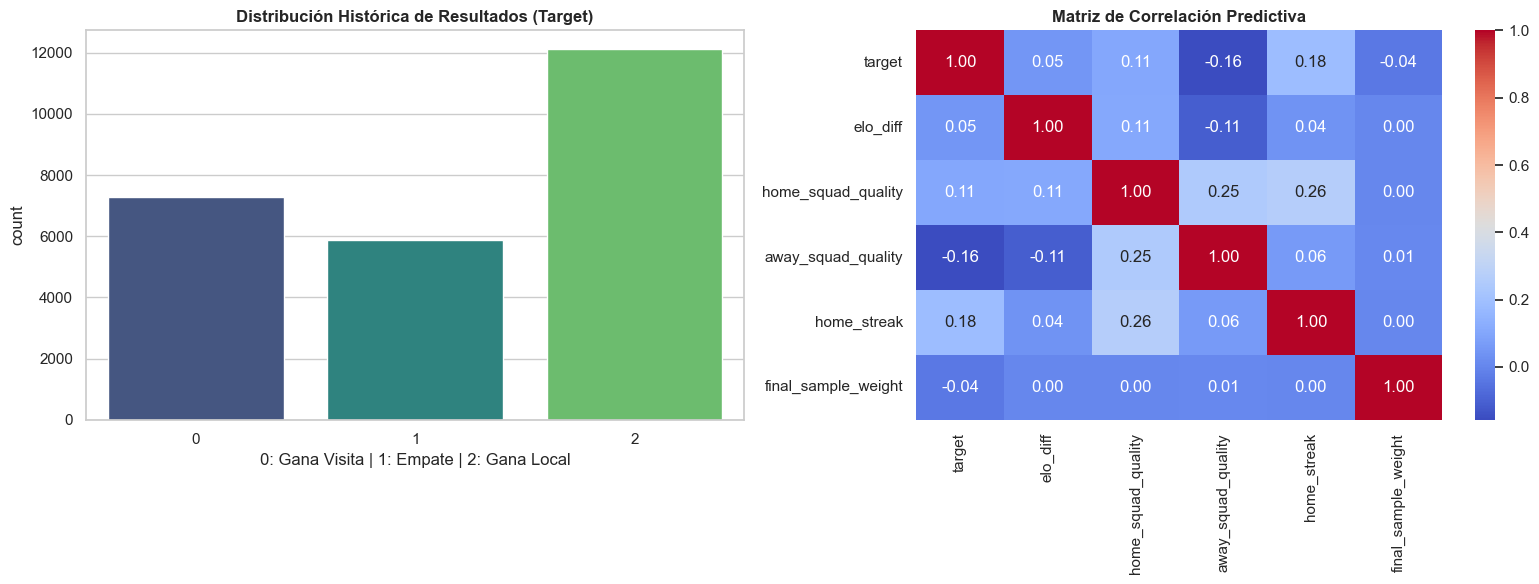

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df_plot = pd.read_csv('data/processed/model_ready_data.csv')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico A: Balance de Clases
sns.countplot(data=df_plot, x='target', palette='viridis', ax=axes[0])
axes[0].set_title('Distribución Histórica de Resultados (Target)', fontweight='bold')
axes[0].set_xlabel('0: Gana Visita | 1: Empate | 2: Gana Local')

# Gráfico B: Matriz de Correlación
features_cols = ['target', 'elo_diff', 'home_squad_quality', 'away_squad_quality', 'home_streak', 'final_sample_weight']
sns.heatmap(df_plot[features_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1])
axes[1].set_title('Matriz de Correlación Predictiva', fontweight='bold')

plt.tight_layout()
plt.show()

**Fase 4: Entrenamiento y Sintonización de Modelos**
Compararemos Regresión Logística contra XGBoost. Utilizaremos `GridSearchCV` para buscar hiperparámetros que combatan el overfitting. Las métricas a observar serán *Log-Loss* y *Multiclass Brier Score*, ya que castigan fuertemente a los modelos que arrojan probabilidades mal calibradas.

In [20]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss
from xgboost import XGBClassifier
import joblib

print("Entrenando Modelos de Machine Learning...")

def multiclass_brier_score(y_true, y_prob):
    y_true_dummies = pd.get_dummies(y_true).values
    return np.mean(np.sum((y_prob - y_true_dummies)**2, axis=1))

df_ml = pd.read_csv('data/processed/model_ready_data.csv')
df_ml['date'] = pd.to_datetime(df_ml['date'])

FEATURES = [
    'home_advantage', 'home_elo', 'away_elo', 'elo_diff', 
    'home_squad_quality', 'away_squad_quality', 
    'home_gdp', 'away_gdp', 'home_streak', 'away_streak', 
    'final_sample_weight'
]

mask_train = df_ml['date'] < '2022-11-20'
mask_test = (df_ml['date'] >= '2022-11-20') & (df_ml['date'] <= '2022-12-18')

X_train, y_train = df_ml.loc[mask_train, FEATURES], df_ml.loc[mask_train, 'target']
X_test, y_test = df_ml.loc[mask_test, FEATURES], df_ml.loc[mask_test, 'target']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
joblib.dump(scaler, 'models/scaler.pkl')

# Regresión Logística (Baseline)
lr = LogisticRegression(solver='lbfgs', max_iter=1000)
grid_lr = GridSearchCV(lr, {'C': [0.1, 1, 10]}, cv=3, scoring='neg_log_loss')
grid_lr.fit(X_train_scaled, y_train)
model_lr = grid_lr.best_estimator_

# XGBoost (Tuning)
xgb = XGBClassifier(objective='multi:softprob', num_class=3, eval_metric='mlogloss')
param_grid = {
    'max_depth': [3, 5],
    'learning_rate': [0.05],
    'n_estimators': [100, 200],
    'subsample': [0.8], 'colsample_bytree': [0.8]
}
grid_xgb = GridSearchCV(xgb, param_grid, cv=3, scoring='neg_log_loss')
grid_xgb.fit(X_train_scaled, y_train)
model_xgb = grid_xgb.best_estimator_
joblib.dump(model_xgb, 'models/xgboost_model.pkl')

# Evaluación
lr_probs = model_lr.predict_proba(X_test_scaled)
xgb_probs = model_xgb.predict_proba(X_test_scaled)

print("-" * 50)
print(f"Logística -> Log-Loss: {log_loss(y_test, lr_probs):.4f} | Brier: {multiclass_brier_score(y_test, lr_probs):.4f}")
print(f"XGBoost   -> Log-Loss: {log_loss(y_test, xgb_probs):.4f} | Brier: {multiclass_brier_score(y_test, xgb_probs):.4f}")
print("-" * 50)
print("Entrenamiento completado y XGBoost guardado en 'models/'.")

Entrenando Modelos de Machine Learning...
--------------------------------------------------
Logística -> Log-Loss: 1.0751 | Brier: 0.6310
XGBoost   -> Log-Loss: 1.0012 | Brier: 0.5940
--------------------------------------------------
Entrenamiento completado y XGBoost guardado en 'models/'.


**Fase 5: Simulación del Torneo (Monte Carlo - 10,000 iteraciones)**
Integrando el formato extendido de la FIFA para 2026 (48 equipos y dieciseisavos de final), ejecutaremos nuestro algoritmo probabilístico. Para asegurar el progreso, implementaremos un sistema de escritura secuencial (*checkpointing*) directo a un archivo CSV.

In [21]:
import random
import csv
from collections import Counter

xgb_model = joblib.load('models/xgboost_model.pkl')
scaler = joblib.load('models/scaler.pkl')

EQUIPOS_48 = [
    'Mexico', 'Poland', 'Angola', 'New Zealand', 'Canada', 'Germany', 'Chile', 'Iraq',
    'United States', 'Senegal', 'Japan', 'Wales', 'Argentina', 'Sweden', 'Nigeria', 'Uzbekistan',
    'France', 'Ecuador', 'South Korea', 'Jamaica', 'Spain', 'Morocco', 'Serbia', 'Costa Rica',
    'England', 'Colombia', 'Algeria', 'Australia', 'Brazil', 'Croatia', 'Cameroon', 'Saudi Arabia',
    'Belgium', 'Uruguay', 'Mali', 'Honduras', 'Netherlands', 'Denmark', 'Egypt', 'Panama',
    'Portugal', 'Switzerland', 'Ivory Coast', 'Curacao', 'Italy', 'Peru', 'Tunisia', 'United Arab Emirates'
]

# Reconstruir diccionarios para la simulación
df_elo = pd.read_csv('data/raw/elo_ratings.csv')
df_sq = pd.read_csv('data/raw/squad_quality.csv')
df_gdp = pd.read_csv('data/raw/socioeconomic_data.csv')

elo_dict = dict(zip(df_elo['team'], df_elo['elo_rating']))
sq_dict = dict(zip(df_sq['team'], df_sq['squad_quality_rating']))
gdp_dict = dict(zip(df_gdp['team'], df_gdp['gdp_ppp_millions']))

STATS = {}
for eq in EQUIPOS_48:
    STATS[eq] = {'elo': elo_dict.get(eq, 1300), 'sq': sq_dict.get(eq, 5.0), 'gdp': gdp_dict.get(eq, 20000)}

def realizar_sorteo_fifa():
    eq_ord = sorted(EQUIPOS_48, key=lambda x: STATS[x]['elo'], reverse=True)
    bombos = [eq_ord[0:12], eq_ord[12:24], eq_ord[24:36], eq_ord[36:48]]
    for b in bombos: random.shuffle(b)
    return {f'Grp_{i+1}': [bombos[0][i], bombos[1][i], bombos[2][i], bombos[3][i]] for i in range(12)}

def simular_partido(equipo_a, equipo_b, es_eliminatoria=False):
    is_home_a = 1 if equipo_a in ['United States', 'Mexico', 'Canada'] else 0
    vector = pd.DataFrame([[
        is_home_a, STATS[equipo_a]['elo'], STATS[equipo_b]['elo'], STATS[equipo_a]['elo'] - STATS[equipo_b]['elo'], 
        STATS[equipo_a]['sq'], STATS[equipo_b]['sq'], STATS[equipo_a]['gdp'], STATS[equipo_b]['gdp'], 
        1.5, 1.5, 1.0 
    ]], columns=FEATURES)
    
    probs = xgb_model.predict_proba(scaler.transform(vector))[0]
    prob_b, prob_empate, prob_a = probs[0], probs[1], probs[2]
    
    if es_eliminatoria:
        prob_a += prob_empate * (prob_a / (prob_a + prob_b))
        prob_b += prob_empate * (prob_b / (prob_a + prob_b))
        p_final = np.array([prob_a, prob_b]) / sum([prob_a, prob_b])
        return np.random.choice([equipo_a, equipo_b], p=p_final)
    else:
        p_final = np.array([prob_a, prob_empate, prob_b]) / sum([prob_a, prob_empate, prob_b])
        res = np.random.choice([2, 1, 0], p=p_final)
        return equipo_a if res == 2 else (equipo_b if res == 0 else 'Empate')

def simular_torneo():
    grupos = realizar_sorteo_fifa()
    puntos = {eq: 0 for eq in EQUIPOS_48}
    clasificados, terceros = [], []
    
    for g, eqps in grupos.items():
        for i in range(len(eqps)):
            for j in range(i+1, len(eqps)):
                res = simular_partido(eqps[i], eqps[j])
                if res == eqps[i]: puntos[eqps[i]] += 3
                elif res == eqps[j]: puntos[eqps[j]] += 3
                else: puntos[eqps[i]] += 1; puntos[eqps[j]] += 1
        
        ord_eqps = sorted(eqps, key=lambda x: puntos[x], reverse=True)
        clasificados.extend(ord_eqps[:2])
        terceros.append(ord_eqps[2])
    
    ronda_32 = clasificados + sorted(terceros, key=lambda x: puntos[x], reverse=True)[:8]
    random.shuffle(ronda_32)
    
    rondas = [ronda_32]
    while len(rondas[-1]) > 1:
        siguiente = [simular_partido(rondas[-1][i], rondas[-1][i+1], True) for i in range(0, len(rondas[-1]), 2)]
        rondas.append(siguiente)
    
    return rondas[-1][0]

ITERACIONES = 10000
csv_path = 'data/processed/simulations_grid.csv'
open(csv_path, 'w').close()

print(f"Iniciando Simulación de {ITERACIONES} torneos...")
campeones, fila_buffer = [], []

for i in range(ITERACIONES):
    ganador = simular_torneo()
    campeones.append(ganador)
    fila_buffer.append(ganador)
    
    if len(fila_buffer) == 20:
        with open(csv_path, 'a', newline='', encoding='utf-8') as f:
            csv.writer(f).writerow(fila_buffer)
        fila_buffer = []
        
    if (i+1) % 1000 == 0: 
        print(f"   -> Progreso: {i+1} mundiales simulados y asegurados en disco.")

print("Simulación Masiva Completada.")

Iniciando Simulación de 10000 torneos en la nube...
   -> Progreso: 1000 mundiales simulados y asegurados en disco.
   -> Progreso: 2000 mundiales simulados y asegurados en disco.
   -> Progreso: 3000 mundiales simulados y asegurados en disco.
   -> Progreso: 4000 mundiales simulados y asegurados en disco.
   -> Progreso: 5000 mundiales simulados y asegurados en disco.
   -> Progreso: 6000 mundiales simulados y asegurados en disco.
   -> Progreso: 7000 mundiales simulados y asegurados en disco.
   -> Progreso: 8000 mundiales simulados y asegurados en disco.
   -> Progreso: 9000 mundiales simulados y asegurados en disco.
   -> Progreso: 10000 mundiales simulados y asegurados en disco.
Simulación Masiva Completada.


**Fase 6: Resultados Finales del Oráculo (Análisis Visual)**
A continuación, analizaremos los resultados de la simulación masiva sin necesidad de reejecutar el modelo. Extraeremos las métricas de probabilidad y visualizaremos el Top 10 de selecciones con mayores opciones estadísticas de coronarse campeones del mundo en 2026.

TOP 5: PREDICCIÓN DEL CAMPEÓN MUNDIAL 2026
   Basado en 10000 simulaciones de Monte Carlo
 Rk.  | Selección          | Probabilidad    | Victorias
-----------------------------------------------------------------
 1   | SPAIN              | 12.23% (±0.64%) | 1223
 2   | FRANCE             | 12.19% (±0.64%) | 1219
 3   | ARGENTINA          | 09.95% (±0.59%) | 995
 4   | NETHERLANDS        | 07.87% (±0.53%) | 787
 5   | GERMANY            | 06.80% (±0.49%) | 680


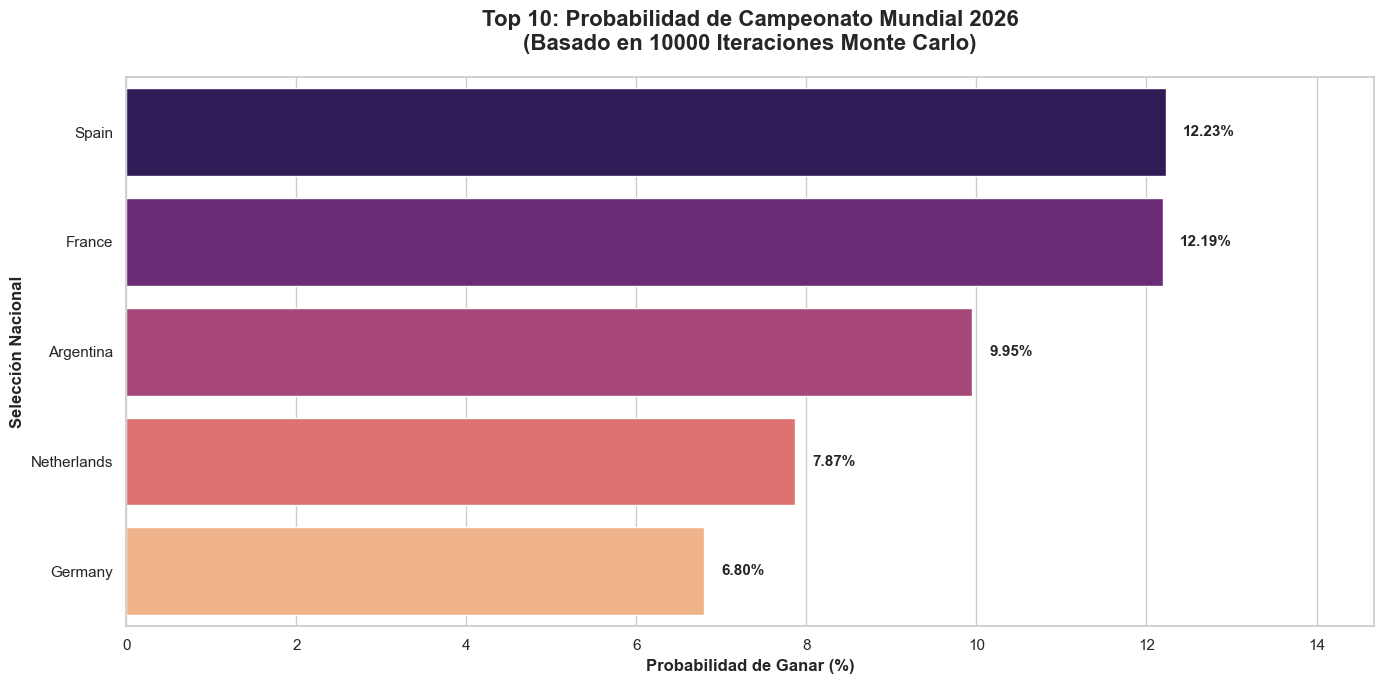

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os

# 1. Recuperar los datos
csv_path = 'data/processed/simulations_grid.csv'
if os.path.exists(csv_path):
    df_sim = pd.read_csv(csv_path, header=None)
    campeones = df_sim.values.flatten()
    campeones = [c for c in campeones if pd.notna(c)]
else:
    print("No se encontró el CSV. Asegúrate de haber corrido la simulación.")
    campeones = []

TOTAL_ITERACIONES = len(campeones)

if TOTAL_ITERACIONES > 0:
    # 2. Extraer el Top 5
    top_5 = Counter(campeones).most_common(5)
    equipos = [x[0] for x in top_5]
    probabilidades = [(x[1] / TOTAL_ITERACIONES) * 100 for x in top_5]

    # 3. SALIDA EN TEXTO
    print("="*65)
    print(f"TOP 5: PREDICCIÓN DEL CAMPEÓN MUNDIAL 2026")
    print(f"   Basado en {TOTAL_ITERACIONES} simulaciones de Monte Carlo")
    print("="*65)
    print(f" {'Rk.':<4} | {'Selección':<18} | {'Probabilidad':<15} | {'Victorias'}")
    print("-" * 65)
    for idx, (equipo, victorias) in enumerate(top_5):
        prob = (victorias / TOTAL_ITERACIONES) * 100
        # Margen de Error (Intervalo de confianza del 95%)
        margen = 1.96 * np.sqrt((prob/100) * (1 - prob/100) / TOTAL_ITERACIONES) * 100
        print(f" {idx+1:<4}| {equipo.upper():<18} | {prob:05.2f}% (±{margen:04.2f}%) | {victorias}")
    print("="*65)

    # 4. SALIDA GRÁFICA VISUAL (Para tu documento IEEE)
    plt.figure(figsize=(14, 7))
    
    # Paleta de colores: Destacamos al Top 3 con colores más intensos
    colores = sns.color_palette("magma", len(equipos))
    ax = sns.barplot(x=probabilidades, y=equipos, palette=colores)

    plt.title(f'Top 10: Probabilidad de Campeonato Mundial 2026\n(Basado en {TOTAL_ITERACIONES} Iteraciones Monte Carlo)', 
              fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Probabilidad de Ganar (%)', fontsize=12, fontweight='bold')
    plt.ylabel('Selección Nacional', fontsize=12, fontweight='bold')
    
    # Ajustamos el límite X para que quepa el texto
    plt.xlim(0, max(probabilidades) + (max(probabilidades)*0.2)) 

    # Agregar etiquetas de porcentaje en las barras
    for index, value in enumerate(probabilidades):
        plt.text(value + 0.2, index, f'{value:.2f}%', va='center', fontweight='bold', fontsize=11)

    plt.tight_layout()
    plt.show()